# TinyChirp CNN build pipeline\n
\n
Trains one CNN on log-mel spectrograms, exports an int8 TFLite model, and writes a Rust audio sample file.

In [ ]:
%load_ext autoreload
%autoreload 2
from typing import TYPE_CHECKING
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [ ]:
from building_tensorflow.utils import (
    TARGET_FRAMES_MEL,
    TARGET_AUDIO_LEN_MEL,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("cnn_mel_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs
BATCH_SIZE = 32

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)



2026-04-14 18:11:48.965985: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 18:11:49.052180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 18:11:49.101139: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 18:11:49.101324: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 18:11:49.165750: I tensorflow/core/platform/cpu_feature_gua

Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/cnn_mel_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (mel): 184
Target audio length (mel): 47872


2026-04-14 18:11:53.029427: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 18:11:53.132189: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 18:11:53.133178: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [ ]:
from building_tensorflow.utils import (
    make_mel_datasets,
    NUM_MEL_BINS_MEL,
)

train_ds, val_ds, test_ds, label_names = make_mel_datasets(
    num_mel_bins=NUM_MEL_BINS_MEL,
    target_frames=TARGET_FRAMES_MEL,
)
num_labels = len(label_names)
print("Classes:", label_names)



Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.


2026-04-14 18:11:54.171295: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Classes: ['non_target' 'target']


In [ ]:
from building_tensorflow.utils import NUM_MEL_BINS_MEL, TARGET_FRAMES_MEL, init_wandb, get_callbacks, finish_wandb

CONV_FILTER_SIZE = 3
N_CHANNELS = 4

TARGET_FRAMES = TARGET_FRAMES_MEL
NUM_MEL_BINS = NUM_MEL_BINS_MEL

end_of_conv1_s1 = (TARGET_FRAMES - CONV_FILTER_SIZE + 1) // 2
end_of_conv2_s1 = (end_of_conv1_s1 - CONV_FILTER_SIZE + 1) // 2
end_of_conv1_s2 = (NUM_MEL_BINS - CONV_FILTER_SIZE + 1) // 2
end_of_conv2_s2 = (end_of_conv1_s2 - CONV_FILTER_SIZE + 1) // 2

model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_FRAMES, NUM_MEL_BINS, 1)),
    keras.layers.Conv2D(N_CHANNELS, (CONV_FILTER_SIZE, CONV_FILTER_SIZE), activation="relu"),
    keras.layers.AveragePooling2D((2, 2)),
    keras.layers.Conv2D(N_CHANNELS, (CONV_FILTER_SIZE, CONV_FILTER_SIZE), activation="relu"),
    keras.layers.AveragePooling2D((2, 2)),
    keras.layers.Reshape((end_of_conv2_s2 * end_of_conv2_s1 * N_CHANNELS,)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(num_labels),
])
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)



init_wandb("cnn_mel", config={
    "conv_filter_size": CONV_FILTER_SIZE,
    "n_channels": N_CHANNELS,
})

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/50


I0000 00:00:1776183119.086498    5804 service.cc:145] XLA service 0x74a95400b150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776183119.086522    5804 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-14 18:11:59.142393: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 18:11:59.395093: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 22/353 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5810 - loss: 0.9050

I0000 00:00:1776183121.118519    5804 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.9171 - loss: 0.2155 - val_accuracy: 0.9674 - val_loss: 0.0997
Epoch 2/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9656 - loss: 0.0949 - val_accuracy: 0.9768 - val_loss: 0.0817
Epoch 3/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9733 - loss: 0.0712 - val_accuracy: 0.9783 - val_loss: 0.0623
Epoch 4/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9845 - loss: 0.0440 - val_accuracy: 0.9848 - val_loss: 0.0581
Epoch 5/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9879 - loss: 0.0347 - val_accuracy: 0.9841 - val_loss: 0.0583
Epoch 6/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.9896 - loss: 0.0284 - val_accuracy: 0.9884 - val_loss: 0.0617
Epoch 7/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9935 - loss: 0.0189 - val_accuracy: 0.9906 - val_loss: 0.0521
Epoch 8/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9961 - loss: 0.0135 - val_accurac

batch/accuracy,▁▇▇▇▇███████████████████████████████████
batch/batch_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▅▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▅▆▇▇▇▇██████████████████
epoch/epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▄▆▆▇▇▇▇▇█▇▇▇█▇███▇███▇█
epoch/val_loss,█▆▃▃▃▃▂▄▂▁▃▃▃▁▁▂▅▃▄▆▃▃▄▅▅
batch/accuracy,0.99991


353it [00:18, 20.25it/s]2026-04-14 18:20:57.585603: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
353it [00:18, 19.37it/s]
44it [00:02, 20.21it/s]2026-04-14 18:20:59.995810: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



=== Binary classifier metrics : TEST SET===
Threshold: 0.5945  (best F2 threshold)
Accuracy : 0.9878
Precision: 0.9662
Recall   : 0.9978
F2 score : 0.9913
=== Binary classifier metrics : TRAIN SET===
AUC      : 1.0000


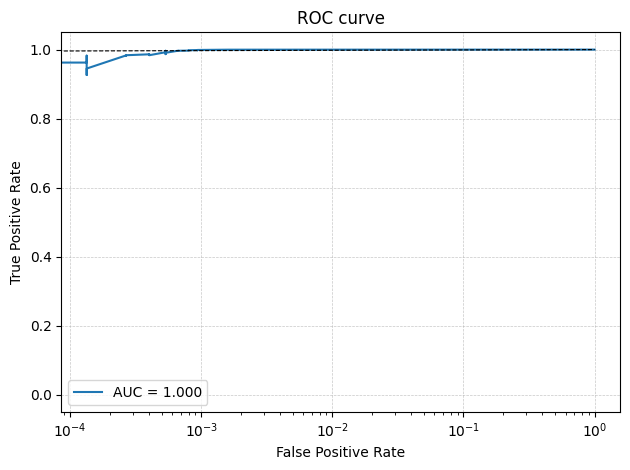

In [ ]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics

train_metrics, test_metrics = evaluate_binary_classifier(model, train_ds, test_ds)
display_eval_metrics(train_metrics, test_metrics)

In [ ]:
from building_tensorflow.utils import (
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

val_specs = build_representative_batches(test_ds, TARGET_AUDIO_LEN_MEL, take=100)

try:
    export_keras_model_to_int8_tflite(model, val_specs, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"Conversion failed: {e}")

ValueError: cannot reshape array of size 14720 into shape (1,47872,1)

In [ ]:
from building_tensorflow.utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, "cnn_mel_tf", train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")